<a href="https://colab.research.google.com/github/tirupari57/AI-Course/blob/main/CaseStudy_EDA_Financial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Inspect the dataframe

In [2]:

# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Reading the data

In [5]:
applicationData = pd.read_csv('applicationdata.csv')
previousapplication = pd.read_csv('previousapplication.csv')

Missing Data Audit & Analysis

In [9]:
display(applicationData.head())
display(previousapplication.head())

display(applicationData.info())
display(previousapplication.info())



,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

None

SK_ID_CURR                    0.000000
TARGET                        0.000000
NAME_CONTRACT_TYPE            0.000000
CODE_GENDER                   0.000000
FLAG_OWN_CAR                  0.000000
                                ...   
AMT_REQ_CREDIT_BUREAU_DAY     0.135016
AMT_REQ_CREDIT_BUREAU_WEEK    0.135016
AMT_REQ_CREDIT_BUREAU_MON     0.135016
AMT_REQ_CREDIT_BUREAU_QRT     0.135016
AMT_REQ_CREDIT_BUREAU_YEAR    0.135016
Length: 122, dtype: float64


### Missing Data in `applicationData`

The following code calculates the total number and percentage of missing values for each column in the `applicationData` DataFrame. It then displays only those columns that have at least one missing value, sorted in descending order of missing values.

In [16]:
total_missing_app = applicationData.isnull().sum().sort_values(ascending=False)
percent_missing_app = (applicationData.isnull().sum()/applicationData.isnull().count()*100).sort_values(ascending=False)
missing_application_data = pd.concat([total_missing_app, percent_missing_app], axis=1, keys=['Total Missing', 'Percent Missing'])
display(missing_application_data[missing_application_data['Total Missing'] > 0])

,Total Missing,Percent Missing
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
...,...,...
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


Similarly, this code calculates and displays the missing data audit for the `previousapplication` DataFrame, showing columns with missing values and their respective counts and percentages.

### Missing Data in `previousapplication`

In [17]:
total_missing_prev = previousapplication.isnull().sum().sort_values(ascending=False)
percent_missing_prev = (previousapplication.isnull().sum()/previousapplication.isnull().count()*100).sort_values(ascending=False)
missing_previous_data = pd.concat([total_missing_prev, percent_missing_prev], axis=1, keys=['Total Missing', 'Percent Missing'])
display(missing_previous_data[missing_previous_data['Total Missing'] > 0])

,Total Missing,Percent Missing
RATE_INTEREST_PRIVILEGED,1664263,99.643698
RATE_INTEREST_PRIMARY,1664263,99.643698
AMT_DOWN_PAYMENT,895844,53.636480
RATE_DOWN_PAYMENT,895844,53.636480
NAME_TYPE_SUITE,820405,49.119754
DAYS_TERMINATION,673065,40.298129
DAYS_FIRST_DRAWING,673065,40.298129
DAYS_FIRST_DUE,673065,40.298129
DAYS_LAST_DUE_1ST_VERSION,673065,40.298129
DAYS_LAST_DUE,673065,40.298129


From the audit, we can see that both dataframes have a significant amount of missing data in various columns. Specifically, `applicationData` has columns like `COMMONAREA_MEDI`, `COMMONAREA_AVG`, `COMMONAREA_MODE` with over 69% missing values, and `previousapplication` has columns such as `RATE_INTEREST_PRIMARY` and `RATE_INTEREST_PRIVILEGED` with almost 100% missing values.

2. Data cleaning - DROP COLUMNS WITH > 40% MISSING DATA

First, let's identify the columns in `applicationData` that have more than 40% missing values.

In [20]:
missing_cols_app = percent_missing_app[percent_missing_app > 40].index.tolist()
print(f"Columns to drop from applicationData due to >40% missing values: {missing_cols_app}")
applicationData.drop(columns=missing_cols_app, inplace=True, errors='ignore')
print(f"Remaining columns in applicationData: {applicationData.shape[1]}")

Columns to drop from applicationData due to >40% missing values: ['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE', 'LANDAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MODE', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'HOUSETYPE_MODE', 'FLOORSMAX_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEA

Next, we will do the same for the `previousapplication` DataFrame.

In [21]:
missing_cols_prev = percent_missing_prev[percent_missing_prev > 40].index.tolist()
print(f"Columns to drop from previousapplication due to >40% missing values: {missing_cols_prev}")
previousapplication.drop(columns=missing_cols_prev, inplace=True, errors='ignore')
print(f"Remaining columns in previousapplication: {previousapplication.shape[1]}")

Columns to drop from previousapplication due to >40% missing values: ['RATE_INTEREST_PRIVILEGED', 'RATE_INTEREST_PRIMARY', 'AMT_DOWN_PAYMENT', 'RATE_DOWN_PAYMENT', 'NAME_TYPE_SUITE', 'DAYS_TERMINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'NFLAG_INSURED_ON_APPROVAL']
Remaining columns in previousapplication: 26


The columns with more than 40% missing data have been dropped from both `applicationData` and `previousapplication` DataFrames. This helps in reducing noise and potentially improving model performance by removing features with too many unknown values.

2.1 IMPUTATION FOR REMAINING COLUMNS

### Imputation for `applicationData`
Let's first handle the `applicationData` DataFrame.

In [22]:
# Identify numerical and categorical columns with missing values in applicationData
numerical_cols_app = applicationData.select_dtypes(include=np.number).columns
categorical_cols_app = applicationData.select_dtypes(include='object').columns

# Impute numerical columns with median
for col in numerical_cols_app:
    if applicationData[col].isnull().any():
        median_val = applicationData[col].median()
        applicationData[col].fillna(median_val, inplace=True)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in categorical_cols_app:
    if applicationData[col].isnull().any():
        mode_val = applicationData[col].mode()[0] # mode() returns a Series, so take the first element
        applicationData[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation in applicationData:")
display(applicationData.isnull().sum()[applicationData.isnull().sum() > 0])

/tmp/ipykernel_1206/4207704343.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applicationData[col].fillna(median_val, inplace=True)


Imputed numerical column 'AMT_ANNUITY' with median: 24903.0
Imputed numerical column 'AMT_GOODS_PRICE' with median: 450000.0
Imputed numerical column 'CNT_FAM_MEMBERS' with median: 2.0
Imputed numerical column 'EXT_SOURCE_2' with median: 0.5659614260608526
Imputed numerical column 'EXT_SOURCE_3' with median: 0.5352762504724826
Imputed numerical column 'OBS_30_CNT_SOCIAL_CIRCLE' with median: 0.0
Imputed numerical column 'DEF_30_CNT_SOCIAL_CIRCLE' with median: 0.0
Imputed numerical column 'OBS_60_CNT_SOCIAL_CIRCLE' with median: 0.0
Imputed numerical column 'DEF_60_CNT_SOCIAL_CIRCLE' with median: 0.0
Imputed numerical column 'DAYS_LAST_PHONE_CHANGE' with median: -757.0
Imputed numerical column 'AMT_REQ_CREDIT_BUREAU_HOUR' with median: 0.0
Imputed numerical column 'AMT_REQ_CREDIT_BUREAU_DAY' with median: 0.0
Imputed numerical column 'AMT_REQ_CREDIT_BUREAU_WEEK' with median: 0.0
Imputed numerical column 'AMT_REQ_CREDIT_BUREAU_MON' with median: 0.0
Imputed numerical column 'AMT_REQ_CREDIT_BU

/tmp/ipykernel_1206/4207704343.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applicationData[col].fillna(mode_val, inplace=True)


Imputed categorical column 'NAME_TYPE_SUITE' with mode: Unaccompanied
Imputed categorical column 'OCCUPATION_TYPE' with mode: Laborers

Missing values after imputation in applicationData:


,0


### Imputation for `previousapplication`
Now, let's handle the `previousapplication` DataFrame.

In [23]:
# Identify numerical and categorical columns with missing values in previousapplication
numerical_cols_prev = previousapplication.select_dtypes(include=np.number).columns
categorical_cols_prev = previousapplication.select_dtypes(include='object').columns

# Impute numerical columns with median
for col in numerical_cols_prev:
    if previousapplication[col].isnull().any():
        median_val = previousapplication[col].median()
        previousapplication[col].fillna(median_val, inplace=True)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in categorical_cols_prev:
    if previousapplication[col].isnull().any():
        mode_val = previousapplication[col].mode()[0] # mode() returns a Series, so take the first element
        previousapplication[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation in previousapplication:")
display(previousapplication.isnull().sum()[previousapplication.isnull().sum() > 0])

/tmp/ipykernel_1206/2838619863.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  previousapplication[col].fillna(median_val, inplace=True)


Imputed numerical column 'AMT_ANNUITY' with median: 11250.0
Imputed numerical column 'AMT_CREDIT' with median: 80541.0
Imputed numerical column 'AMT_GOODS_PRICE' with median: 112320.0
Imputed numerical column 'CNT_PAYMENT' with median: 12.0


/tmp/ipykernel_1206/2838619863.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  previousapplication[col].fillna(mode_val, inplace=True)


Imputed categorical column 'PRODUCT_COMBINATION' with mode: Cash

Missing values after imputation in previousapplication:


,0


All remaining missing values in both `applicationData` and `previousapplication` have been imputed using the median for numerical columns and the mode for categorical columns. Both DataFrames should now be free of missing values.

**Why use Median instead of Mean for continuous numerical features in banking?**


Using the median instead of the mean for imputing missing continuous numerical features, especially in banking, is generally preferred due to its robustness to outliers and skewed data distributions. Here's why:

Robustness to Outliers: Financial datasets often contain outliers (e.g., unusually high incomes, very large loan amounts, or extremely low values). The mean is highly sensitive to these extreme values, meaning a few outliers can significantly shift the average. The median, being the middle value in a sorted dataset, is not affected by the magnitude of these outliers, making it a more stable and representative central tendency measure.

Skewed Distributions: Banking data often exhibits skewed distributions. For example, income distributions are typically right-skewed, with many people earning lower to moderate incomes and a few individuals earning very high incomes. In a skewed distribution, the mean can be pulled towards the tail, making it a poor representation of the 'typical' value. The median, however, accurately reflects the central tendency even in skewed data.

Preservation of Data Characteristics: By using the median, you are less likely to introduce bias or distortion into the dataset due to extreme values. This can be crucial for downstream analysis and machine learning models, as it helps maintain the original patterns and relationships within the data more effectively than mean imputation would.

In summary, the median provides a more reliable and less misleading estimate for missing values when dealing with the often-outlier-prone and skewed nature of financial data, leading to more robust models and conclusions.

## **Interquartile Range ($IQR$).**

In [25]:
q1 = applicationData['AMT_INCOME_TOTAL'].quantile(0.25)
q3 = applicationData['AMT_INCOME_TOTAL'].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - (1.5 * iqr)
upper_limit = q3 + (1.5 * iqr)

print(f"Income IQR: {iqr}")
print(f"Mathematical Outlier Thresholds: Lower Limit = {lower_limit}, Upper Limit = {upper_limit}")

Income IQR: 90000.0
Mathematical Outlier Thresholds: Lower Limit = -22500.0, Upper Limit = 337500.0


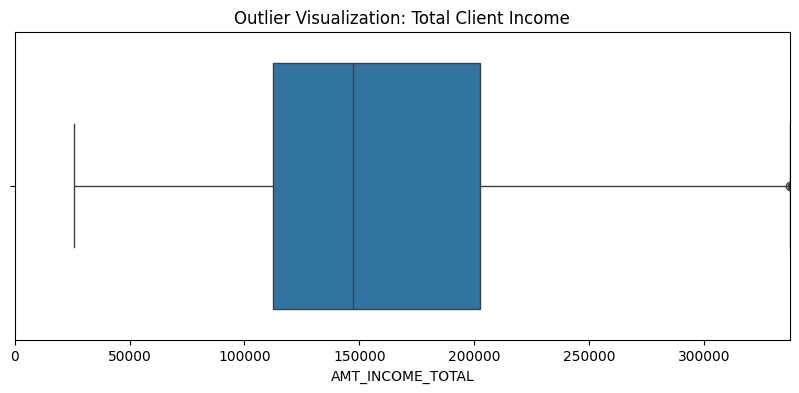

In [31]:
# ==========================================
## VISUALIZE OUTLIERS
# ==========================================
plt.figure(figsize=(10, 4))
sns.boxplot(x=applicationData['AMT_INCOME_TOTAL'])
plt.title('Outlier Visualization: Total Client Income')
plt.xlim(0, upper_limit) # Set x-axis limits to focus on the main distribution
plt.show()